# Toy-manifold noise sweep results

Compare K-means + PCA, vanilla MFA, MFA-HDDC (Adam), and MFA-HDDC (EM) using the two aggregated metrics CSVs.

## 1. Load the dataframes

`general_df` has one row per evaluated run. `manifold_df` has one row per run and manifold; `run_id` connects the tables. EM runs use `model_kind="em"`; HDDC rows with `config.training.arguments.fit_method="em"` are given the same label when loading. Run the notebook from the repository root or `notebooks/`.

Missing (`NaN`) noise ratios denote noiseless runs and are labeled `noiseless`. Use `"noiseless"` (or `float("nan")`) in any noise-level selection list. Ratios are read from `noise_ratio` when present, otherwise from the dataset ID suffix.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

TANGENT_SCORE = "subspace_overlap"  # or "worst_direction_cosine"

DATA_DIR = REPO_ROOT / "dalg-cache/toy_manifolds_10types_1each_D128_30Keach_noise_sweep_seed0"
general_df = pd.read_csv(DATA_DIR / "general_metrics.csv")
manifold_df = pd.read_csv(DATA_DIR / "manifold_metrics.csv")

def noise_key(value):
    # Use a stable key for selection, pivots, and labels: NaN != NaN.
    return "noiseless" if pd.isna(value) or value == "noiseless" else int(value)


for frame in (general_df, manifold_df):
    if "config.training.arguments.fit_method" in frame:
        em_rows = frame["model_kind"].eq("hddc") & frame["config.training.arguments.fit_method"].eq("em")
        frame.loc[em_rows, "model_kind"] = "em"
    ratios = (frame["noise_ratio"] if "noise_ratio" in frame else
              frame["config.dataset.id"].str.extract(r"_noise(\d+)$", expand=False).astype(float))
    frame["noise_ratio"] = ratios.map(noise_key)
N_MANIFOLD_TYPES = manifold_df["type_name"].nunique()

print(f"general_df:  {general_df.shape[0]:,} rows × {general_df.shape[1]} columns")
print(f"manifold_df: {manifold_df.shape[0]:,} rows × {manifold_df.shape[1]} columns")

general_df:  560 rows × 358 columns
manifold_df: 5,600 rows × 256 columns


/tmp/ipykernel_3153393/1471746690.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["noise_ratio"] = ratios.map(noise_key)
/tmp/ipykernel_3153393/1471746690.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["noise_ratio"] = ratios.map(noise_key)


## 2. K and rank selection at a glance

Each figure fixes a model and noise ratio, then shows **K on the rows** and the **rank-selection parameter on the columns**, using the five metrics from the rank recovery table plus average tangent alignment, containment, adjusted alignment, adjusted BIC, and regular BIC.

- HDDC (Adam and EM) and KMeans columns are surgery thresholds. These change learned qₖ, shown in the **Mean qₖ** panel. The MFA/HDDC rank capacity in these CSVs is fixed at 32; this is not a sweep over their configured q capacity.
- Vanilla MFA has no selection threshold, so its columns show rank capacity q (only 32 in these data).
- Rank statistics and tangent scores use an unweighted mean over the available manifold types. Alignment and containment panels use `TANGENT_SCORE` from the data-loading cell (default: `subspace_overlap`) on a fixed 0–1 color scale. NLL and component counts come from the run-level dataframe.
- **Avg adjusted alignment** averages the per-manifold adjusted alignment scores with equal weight. It always uses squared subspace overlap on a 0–1 scale. Scores come from `manifold_df["tangent_adjusted_alignment.subspace_overlap.mean"]`.
- **Adjusted BIC** uses the run-level `bic.value` score: `-standard_bic / n + active_components`, with higher values brighter. The likelihood and active-component count use the training split. Compare thresholds at fixed K, dataset, and split: changing K changes the maximum activity reward. KMeans has no BIC and displays **—**.
- **Regular BIC** uses the run-level `bic.standard_bic`: `-2 log L + p log n`, evaluated on the training split. Lower values are brighter; annotations use scientific notation. KMeans has no BIC and displays **—**.
- The live-component panel displays **live / K** and colors by **percentage live**, making different K values comparable. NLL uses a reversed color scale so lower NLL is brighter; mean qₖ has no preferred direction.

Edit the selections below, then run the separate plotting cell. Lists control order, and `None` includes all available K values or thresholds. Gray **—** cells represent missing runs or unavailable metrics.

In [2]:
# Select models/noise levels and build the metric tables before plotting.
SWEEP_MODELS = ["em"]  # any subset of ["hddc", "em", "kmeans", "mfa"]
SWEEP_NOISE_LEVELS = ["noiseless"]  # include "noiseless" for runs with NaN noise ratio
SWEEP_K_VALUES = None  # e.g. [250, 500, 1000, 2000]
SWEEP_THRESHOLDS = None  # e.g. [0.005, 0.01, 0.05, 0.1]; ignored for vanilla MFA
SWEEP_Q_CAPACITY = 32  # MFA/HDDC/EM capacity; KMeans uses its surgery threshold
SWEEP_METRICS = [
    "qₖ = r (%)", "qₖ = m (%)", "Mean qₖ", "NLL (validation)", "Live / total components",
    "Avg tangent alignment", "Avg tangent containment", "Avg adjusted alignment", "Adjusted BIC", "Regular BIC",
]

sweep_axis_columns = {
    "hddc": "surgery_threshold",
    "em": "surgery_threshold",
    "kmeans": "surgery_threshold",
    "mfa": "q_capacity",
}
sweep_axis_labels = {"hddc": "Surgery threshold", "em": "Surgery threshold",
                     "kmeans": "Surgery threshold", "mfa": "Rank capacity q"}
SWEEP_NOISE_LEVELS = [noise_key(noise) for noise in SWEEP_NOISE_LEVELS]
sweep_noise = general_df["noise_ratio"]
sweep_selected = (
    general_df["model_kind"].isin(SWEEP_MODELS)
    & sweep_noise.isin(SWEEP_NOISE_LEVELS)
    & (general_df["model_kind"].eq("kmeans") | general_df["q_capacity"].eq(SWEEP_Q_CAPACITY))
)
if SWEEP_K_VALUES is not None:
    sweep_selected &= general_df["K"].isin(SWEEP_K_VALUES)
sweep_runs = general_df.loc[sweep_selected].copy()
sweep_runs["noise_ratio"] = sweep_noise.loc[sweep_selected]
sweep_runs["sweep_value"] = float("nan")
for model in SWEEP_MODELS:
    model_rows = sweep_runs["model_kind"].eq(model)
    sweep_runs.loc[model_rows, "sweep_value"] = sweep_runs.loc[model_rows, sweep_axis_columns[model]]
if SWEEP_THRESHOLDS is not None:
    sweep_runs = sweep_runs.loc[
        sweep_runs["model_kind"].eq("mfa") | sweep_runs["sweep_value"].isin(SWEEP_THRESHOLDS)
    ].copy()
assert not sweep_runs.duplicated(["model_kind", "noise_ratio", "K", "sweep_value"]).any(), (
    "Each heatmap cell must select exactly one run."
)

# Give equal weight to the available manifold types.
sweep_rank_columns = ["rank.mean_learned", "rank.exact_match", "ambient_rank.exact_match"]
sweep_tangent_columns = {
    f"tangent_alignment.{TANGENT_SCORE}.mean": "Avg tangent alignment",
    f"tangent_containment.{TANGENT_SCORE}.mean": "Avg tangent containment",
    "tangent_adjusted_alignment.subspace_overlap.mean": "Avg adjusted alignment",
}
sweep_manifolds = manifold_df.loc[manifold_df["run_id"].isin(sweep_runs["run_id"])]
assert not sweep_manifolds.duplicated(["run_id", "type_name"]).any()
assert sweep_manifolds.groupby("run_id").size().reindex(sweep_runs["run_id"]).eq(N_MANIFOLD_TYPES).all()
assert sweep_manifolds[sweep_rank_columns].notna().all().all()
sweep_macro = sweep_manifolds.groupby("run_id")[
    sweep_rank_columns + list(sweep_tangent_columns)
].mean()
sweep_summary = sweep_runs[[
    "run_id", "model_kind", "noise_ratio", "K", "sweep_value", "nll.validation", "components.live", "bic.value", "bic.standard_bic",
]].join(sweep_macro, on="run_id", validate="one_to_one").rename(columns={
    "rank.mean_learned": "Mean qₖ", "rank.exact_match": "qₖ = r (%)",
    "ambient_rank.exact_match": "qₖ = m (%)", "nll.validation": "NLL (validation)",
    "components.live": "Live / total components", "bic.value": "Adjusted BIC",
    "bic.standard_bic": "Regular BIC",
    **sweep_tangent_columns,
})
sweep_summary[["qₖ = r (%)", "qₖ = m (%)"]] *= 100

# Reindex each grid to retain missing combinations as NaN.
sweep_k_values = sorted(general_df["K"].unique()) if SWEEP_K_VALUES is None else SWEEP_K_VALUES
sweep_tables = {}
for model in SWEEP_MODELS:
    if model == "mfa":
        sweep_x_values = [SWEEP_Q_CAPACITY]
    elif SWEEP_THRESHOLDS is not None:
        sweep_x_values = SWEEP_THRESHOLDS
    else:
        sweep_x_values = sorted(general_df.loc[
            general_df["model_kind"].eq(model), sweep_axis_columns[model]
        ].dropna().unique())
    if not len(sweep_x_values):
        print(f"No thresholds available for {model}; skipping its sweep plots.")
        continue
    for noise in SWEEP_NOISE_LEVELS:
        rows = sweep_summary.loc[sweep_summary["model_kind"].eq(model) & sweep_summary["noise_ratio"].eq(noise)]
        sweep_tables[(model, noise)] = {
            metric: rows.pivot(index="K", columns="sweep_value", values=metric).reindex(
                index=sweep_k_values, columns=sweep_x_values,
            )
            for metric in SWEEP_METRICS
        }
print(f"Selected {len(sweep_runs)} runs for {len(sweep_tables)} figures.")

Selected 45 runs for 1 figures.


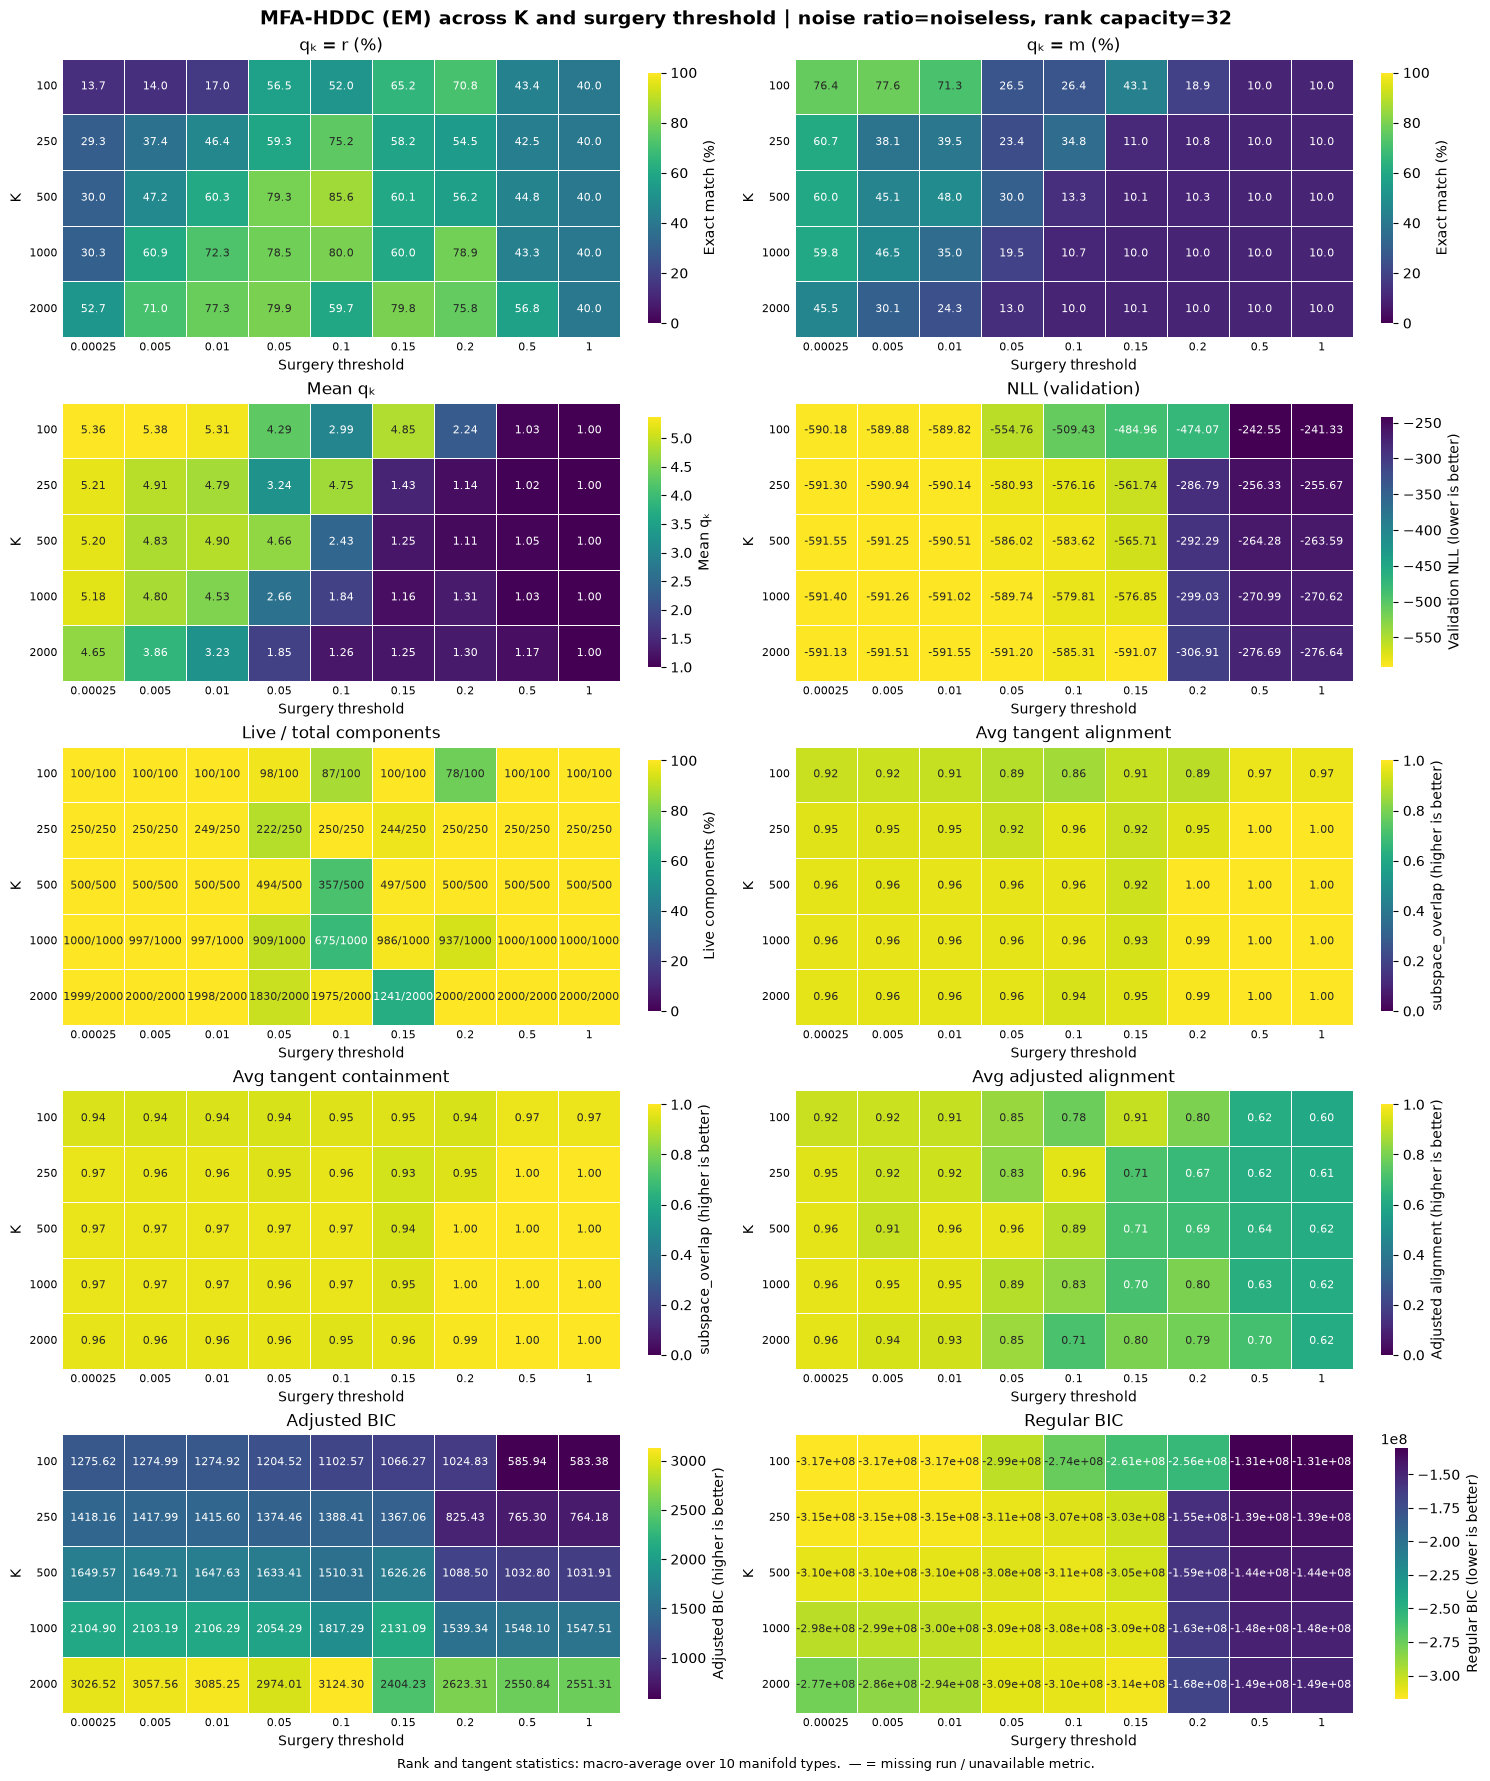

In [3]:
# Plot one dashboard per selected model and noise level.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sweep_model_names = {"hddc": "MFA-HDDC (Adam)", "em": "MFA-HDDC (EM)",
                     "kmeans": "K-means + PCA", "mfa": "Vanilla MFA"}
def plot_sweep_heatmap(ax, metric, table, model):
    """Draw one K/threshold panel with the dashboard scales and annotations."""
    values = table
    annotations = table.map(lambda value: f"{value:.2f}" if pd.notna(value) else "")
    cmap, vmin, vmax, color_label = "viridis", None, None, metric
    if metric in ["qₖ = r (%)", "qₖ = m (%)"]:
        vmin, vmax, color_label = 0, 100, "Exact match (%)"
        annotations = table.map(lambda value: f"{value:.1f}" if pd.notna(value) else "")
    elif metric == "Live / total components":
        values = table.div(table.index, axis="index") * 100
        vmin, vmax, color_label = 0, 100, "Live components (%)"
        annotations = table.copy().astype(object)
        for k in table.index:
            annotations.loc[k] = table.loc[k].map(lambda value: f"{int(value)}/{k}" if pd.notna(value) else "")
    elif metric == "Avg adjusted alignment":
        vmin, vmax, color_label = 0, 1, "Adjusted alignment (higher is better)"
    elif metric in sweep_tangent_columns.values():
        vmin, vmax = 0, 1
        color_label = f"{TANGENT_SCORE} (higher is better)"
    elif metric == "Adjusted BIC":
        color_label = "Adjusted BIC (higher is better)"
    elif metric == "Regular BIC":
        cmap, color_label = "viridis_r", "Regular BIC (lower is better)"
        annotations = table.map(lambda value: f"{value:.2e}" if pd.notna(value) else "")
    elif metric == "NLL (validation)":
        cmap, color_label = "viridis_r", "Validation NLL (lower is better)"
    # Supply a harmless scale when the entire panel is missing.
    if not values.notna().any().any() and vmin is None:
        vmin, vmax = 0, 1
    sns.heatmap(values, ax=ax, annot=annotations, fmt="", cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=0.5, linecolor="white", annot_kws={"fontsize": 8},
                xticklabels=[f"{value:g}" for value in table.columns],
                yticklabels=table.index, cbar=bool(values.notna().any().any()), cbar_kws={"label": color_label, "shrink": 0.9})
    ax.set_facecolor("#e9edf2")
    for row, col in np.argwhere(table.isna().to_numpy()):
        ax.text(col + 0.5, row + 0.5, "—", ha="center", va="center", color="#626b78", fontsize=9)
    ax.set(title=metric, xlabel=sweep_axis_labels[model], ylabel="K")
    ax.tick_params(axis="both", labelrotation=0, labelsize=8, length=0)


for (model, noise), tables in sweep_tables.items():
    ncols = min(2, len(tables))
    nrows = (len(tables) + ncols - 1) // ncols
    grid = next(iter(tables.values()))
    panel_width = max(4.8, 2 + 0.6 * len(grid.columns))
    panel_height = max(2.8, 1.4 + 0.4 * len(grid.index))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * panel_width, nrows * panel_height + 0.7),
                             squeeze=False, layout="constrained", facecolor="white")
    title = f"{sweep_model_names[model]} across K and {sweep_axis_labels[model].lower()} | noise ratio={noise}"
    if model != "kmeans":
        title += f", rank capacity={SWEEP_Q_CAPACITY}"
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for ax, (metric, table) in zip(axes.flat, tables.items()):
        plot_sweep_heatmap(ax, metric, table, model)
    for ax in list(axes.flat)[len(tables):]:
        ax.set_visible(False)
    fig.supxlabel(f"Rank and tangent statistics: macro-average over {N_MANIFOLD_TYPES} manifold types.  — = missing run / unavailable metric.", fontsize=9)
    plt.show()

## 3. Rank recovery table

- Mean qₖ, qₖ = r, and qₖ = m are unweighted averages over the available manifold types, using `rank.mean_learned`, `rank.exact_match`, and `ambient_rank.exact_match` from `manifold_df`. Here r is the intrinsic dimension and m is the manifold embedding dimension. Match fractions are converted to percentages.
- Validation NLL and live/total component counts come directly from `general_df`: `nll.validation`, `components.live`, and `K`.
- Missing KMeans NLL is displayed as an em dash.

### Available configurations

In [4]:
print("K:", sorted(general_df["K"].dropna().unique().tolist()))
print("Thresholds:", sorted(general_df["surgery_threshold"].dropna().unique().tolist()))


K: [100, 250, 500, 1000, 2000]
Thresholds: [0.00025, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.5, 1.0]


In [5]:
# CONFIG
K =500
HDDC_THRESHOLD = 0.01
EM_THRESHOLD = 0.01
KMEANS_THRESHOLD =  0.01
MODEL_NAMES = {"kmeans": "K-means + PCA", "mfa": "Vanilla MFA",
               "hddc": "MFA-HDDC (Adam)", "em": "MFA-HDDC (EM)"}


In [6]:
selected = general_df["K"].eq(K) & (
    general_df["model_kind"].eq("mfa")
    | (general_df["model_kind"].eq("hddc") & general_df["surgery_threshold"].eq(HDDC_THRESHOLD))
    | (general_df["model_kind"].eq("em") & general_df["surgery_threshold"].eq(EM_THRESHOLD))
    | (general_df["model_kind"].eq("kmeans")
       & general_df["surgery_threshold"].eq(KMEANS_THRESHOLD))
)
runs = general_df.loc[selected].copy().set_index("run_id")
assert runs.index.is_unique
assert not runs.empty, "No runs match the selected K and thresholds."
assert not runs.duplicated(["noise_ratio", "model_kind"]).any(), "Expected one run per noise ratio and model."

# Each run has one manifold of each type, so this gives equal weight to all manifold types.
rank_columns = ["rank.mean_learned", "rank.exact_match", "ambient_rank.exact_match"]
manifolds = manifold_df.loc[manifold_df["run_id"].isin(runs.index)]
assert not manifolds.duplicated(["run_id", "type_name"]).any()
assert manifolds.groupby("run_id").size().reindex(runs.index).eq(N_MANIFOLD_TYPES).all()
assert manifolds[rank_columns].notna().all().all()
rank_macro = manifolds.groupby("run_id")[rank_columns].mean()
summary = runs[["model_kind", "noise_ratio", "K", "nll.validation", "components.live"]].join(
    rank_macro, validate="one_to_one"
)
summary["model_order"] = summary["model_kind"].map({model: order for order, model in enumerate(MODEL_NAMES)})
# Noiseless first, followed by decreasing numeric noise ratio.
summary["noise_order"] = summary["noise_ratio"].replace({"noiseless": float("inf")}).astype(float)
summary = summary.sort_values(["noise_order", "model_order"], ascending=[False, True])

rank_table = pd.DataFrame({
    "Model": summary["model_kind"].map(MODEL_NAMES),
    "Noise ratio": summary["noise_ratio"],
    "Mean qₖ": summary["rank.mean_learned"],
    "qₖ = r (%)": 100 * summary["rank.exact_match"],
    "qₖ = m (%)": 100 * summary["ambient_rank.exact_match"],
    "NLL (validation)": summary["nll.validation"],
    "Live / total components": summary["components.live"].astype(str) + " / " + summary["K"].astype(str),
}).reset_index(drop=True)

In [7]:
caption = (
    f"Rank recovery — rank statistics are macro-averages over {N_MANIFOLD_TYPES} manifold types; "
    "live/total are whole-run counts; NLL is an overall validation mean. "
    f"K={K}; HDDC surgery t={HDDC_THRESHOLD:g}; EM surgery t={EM_THRESHOLD:g}; "
    f"KM surgery t={KMEANS_THRESHOLD:g}."
)
display(
    rank_table.style
    .hide(axis="index")
    .format({"Mean qₖ": "{:.2f}", "qₖ = r (%)": "{:.1f}", "qₖ = m (%)": "{:.1f}",
             "NLL (validation)": "{:.2f}"}, na_rep="—")
    .set_caption(caption)
    .set_properties(**{"background-color": "#303344", "color": "#c7d1ef",
                      "padding": "10px 14px", "text-align": "right", "border": "none"})
    .set_properties(subset=["Model"], **{"text-align": "left", "white-space": "nowrap"})
    .set_properties(subset=["qₖ = r (%)", "qₖ = m (%)"],
                    **{"background-color": "#edf3fb", "color": "#34466c", "font-weight": "bold"})
    .set_table_styles([
        {"selector": "", "props": [("border-collapse", "collapse"), ("font-family", "sans-serif")]},
        {"selector": "caption", "props": [("text-align", "left"), ("font-weight", "bold"),
                                           ("padding", "10px"), ("background-color", "#303344"),
                                           ("color", "#c7d1ef")]},
        {"selector": "th", "props": [("background-color", "#414555"), ("color", "#c7d1ef"),
                                      ("padding", "10px 14px"), ("text-align", "right")]},
        *[{"selector": f"tbody tr:nth-child({row + 1}) td",
           "props": [("border-top", "2px solid #718096")]}
          for row in range(1, len(rank_table))
          if rank_table.loc[row, "Noise ratio"] != rank_table.loc[row - 1, "Noise ratio"]],
    ])
)

Model,Noise ratio,Mean qₖ,qₖ = r (%),qₖ = m (%),NLL (validation),Live / total components
K-means + PCA,noiseless,4.98,52.3,57.7,—,500 / 500
Vanilla MFA,noiseless,32.00,0.0,0.0,-585.31,33 / 500
MFA-HDDC (Adam),noiseless,5.71,10.0,98.5,-587.63,469 / 500
MFA-HDDC (EM),noiseless,4.90,60.3,48.0,-590.51,500 / 500
K-means + PCA,1000,4.97,52.6,57.4,—,500 / 500
Vanilla MFA,1000,32.00,0.0,0.0,-578.23,32 / 500
MFA-HDDC (Adam),1000,5.70,10.0,100.0,-583.82,476 / 500
MFA-HDDC (EM),1000,4.86,61.3,46.0,-586.60,500 / 500
K-means + PCA,100,4.97,53.3,56.7,—,500 / 500
Vanilla MFA,100,32.00,0.0,0.0,-416.51,164 / 500


## 4. Tangent geometry, rank, and component counts

Run the selection cell, then run the dedicated plotting cell. It combines all tangent scores into one figure with a 2 × 2 grid of panels and a shared 0–1 color scale. Edit `NOISE_LEVELS` and `MODELS` to choose any subset and column order; each noise level gets one column per selected model. The selection uses `K`, `HDDC_THRESHOLD`, `EM_THRESHOLD`, and `KMEANS_THRESHOLD` from the configuration cell above.

`TANGENT_SCORE` in the data-loading cell chooses `subspace_overlap` (the example figure) or `worst_direction_cosine`. `TANGENT_METRICS` chooses which heatmaps to display. Each cell is a manifold-level mean, with a common color scale from 0 to 1.

**Adjusted alignment** uses the precomputed `tangent_adjusted_alignment.subspace_overlap.mean` column from `manifold_df`. It always uses squared subspace overlap, independently of `TANGENT_SCORE`, with a fixed 0–1 color scale. Gray **—** cells mean no valid contributors or an unavailable run.

The final heatmaps show average learned rank and **associated component counts**, using the same selected runs and row/column order. Counts come from `components.associated` and include components receiving no activation assignments. Each cell displays the count for that manifold and model/noise configuration.


In [8]:
# Select data. List order controls the heatmap columns.
NOISE_LEVELS = ["noiseless", 1000, 100, 10]
MODELS = ["kmeans", "hddc", "em"]  # any subset of ["kmeans", "mfa", "hddc", "em"]
TANGENT_METRICS = {
    "tangent_alignment": "Tangent alignment",
    "tangent_containment": "Tangent containment",
}

assert NOISE_LEVELS and MODELS, "Select at least one noise level and model."
NOISE_LEVELS = [noise_key(noise) for noise in NOISE_LEVELS]
noise_ratio = manifold_df["noise_ratio"]
selected_tangent = (
    manifold_df["K"].eq(K)
    & noise_ratio.isin(NOISE_LEVELS)
    & manifold_df["model_kind"].isin(MODELS)
    & (~manifold_df["model_kind"].eq("hddc") | manifold_df["surgery_threshold"].eq(HDDC_THRESHOLD))
    & (~manifold_df["model_kind"].eq("em") | manifold_df["surgery_threshold"].eq(EM_THRESHOLD))
    & (~manifold_df["model_kind"].eq("kmeans")
       | manifold_df["surgery_threshold"].eq(KMEANS_THRESHOLD))
)
tangent_df = manifold_df.loc[selected_tangent].copy()
tangent_df["noise_ratio"] = noise_ratio.loc[selected_tangent]
assert not tangent_df.duplicated(["noise_ratio", "model_kind", "type_name"]).any(), (
    "Select one run per noise level and model, with one row per manifold type."
)

# Order manifolds by intrinsic dimension r, then embedding dimension m.
manifold_info = (
    manifold_df[["type_name", "intrinsic_dim", "embedding_dim"]].drop_duplicates()
    .sort_values(["intrinsic_dim", "embedding_dim"], kind="stable")
    .set_index("type_name")
)
assert manifold_info.index.is_unique
column_order = pd.MultiIndex.from_product([NOISE_LEVELS, MODELS], names=["noise_ratio", "model_kind"])
tangent_tables = {
    title: tangent_df.pivot(
        index="type_name", columns=["noise_ratio", "model_kind"],
        values=f"{metric}.{TANGENT_SCORE}.mean",
    ).reindex(index=manifold_info.index, columns=column_order)
    for metric, title in TANGENT_METRICS.items()
}
tangent_tables["Adjusted alignment"] = tangent_df.pivot(
    index="type_name", columns=["noise_ratio", "model_kind"],
    values="tangent_adjusted_alignment.subspace_overlap.mean",
).reindex(index=manifold_info.index, columns=column_order)
print(f"Selected {tangent_df['run_id'].nunique()} runs and {len(tangent_df)} manifold rows.")

Selected 12 runs and 120 manifold rows.


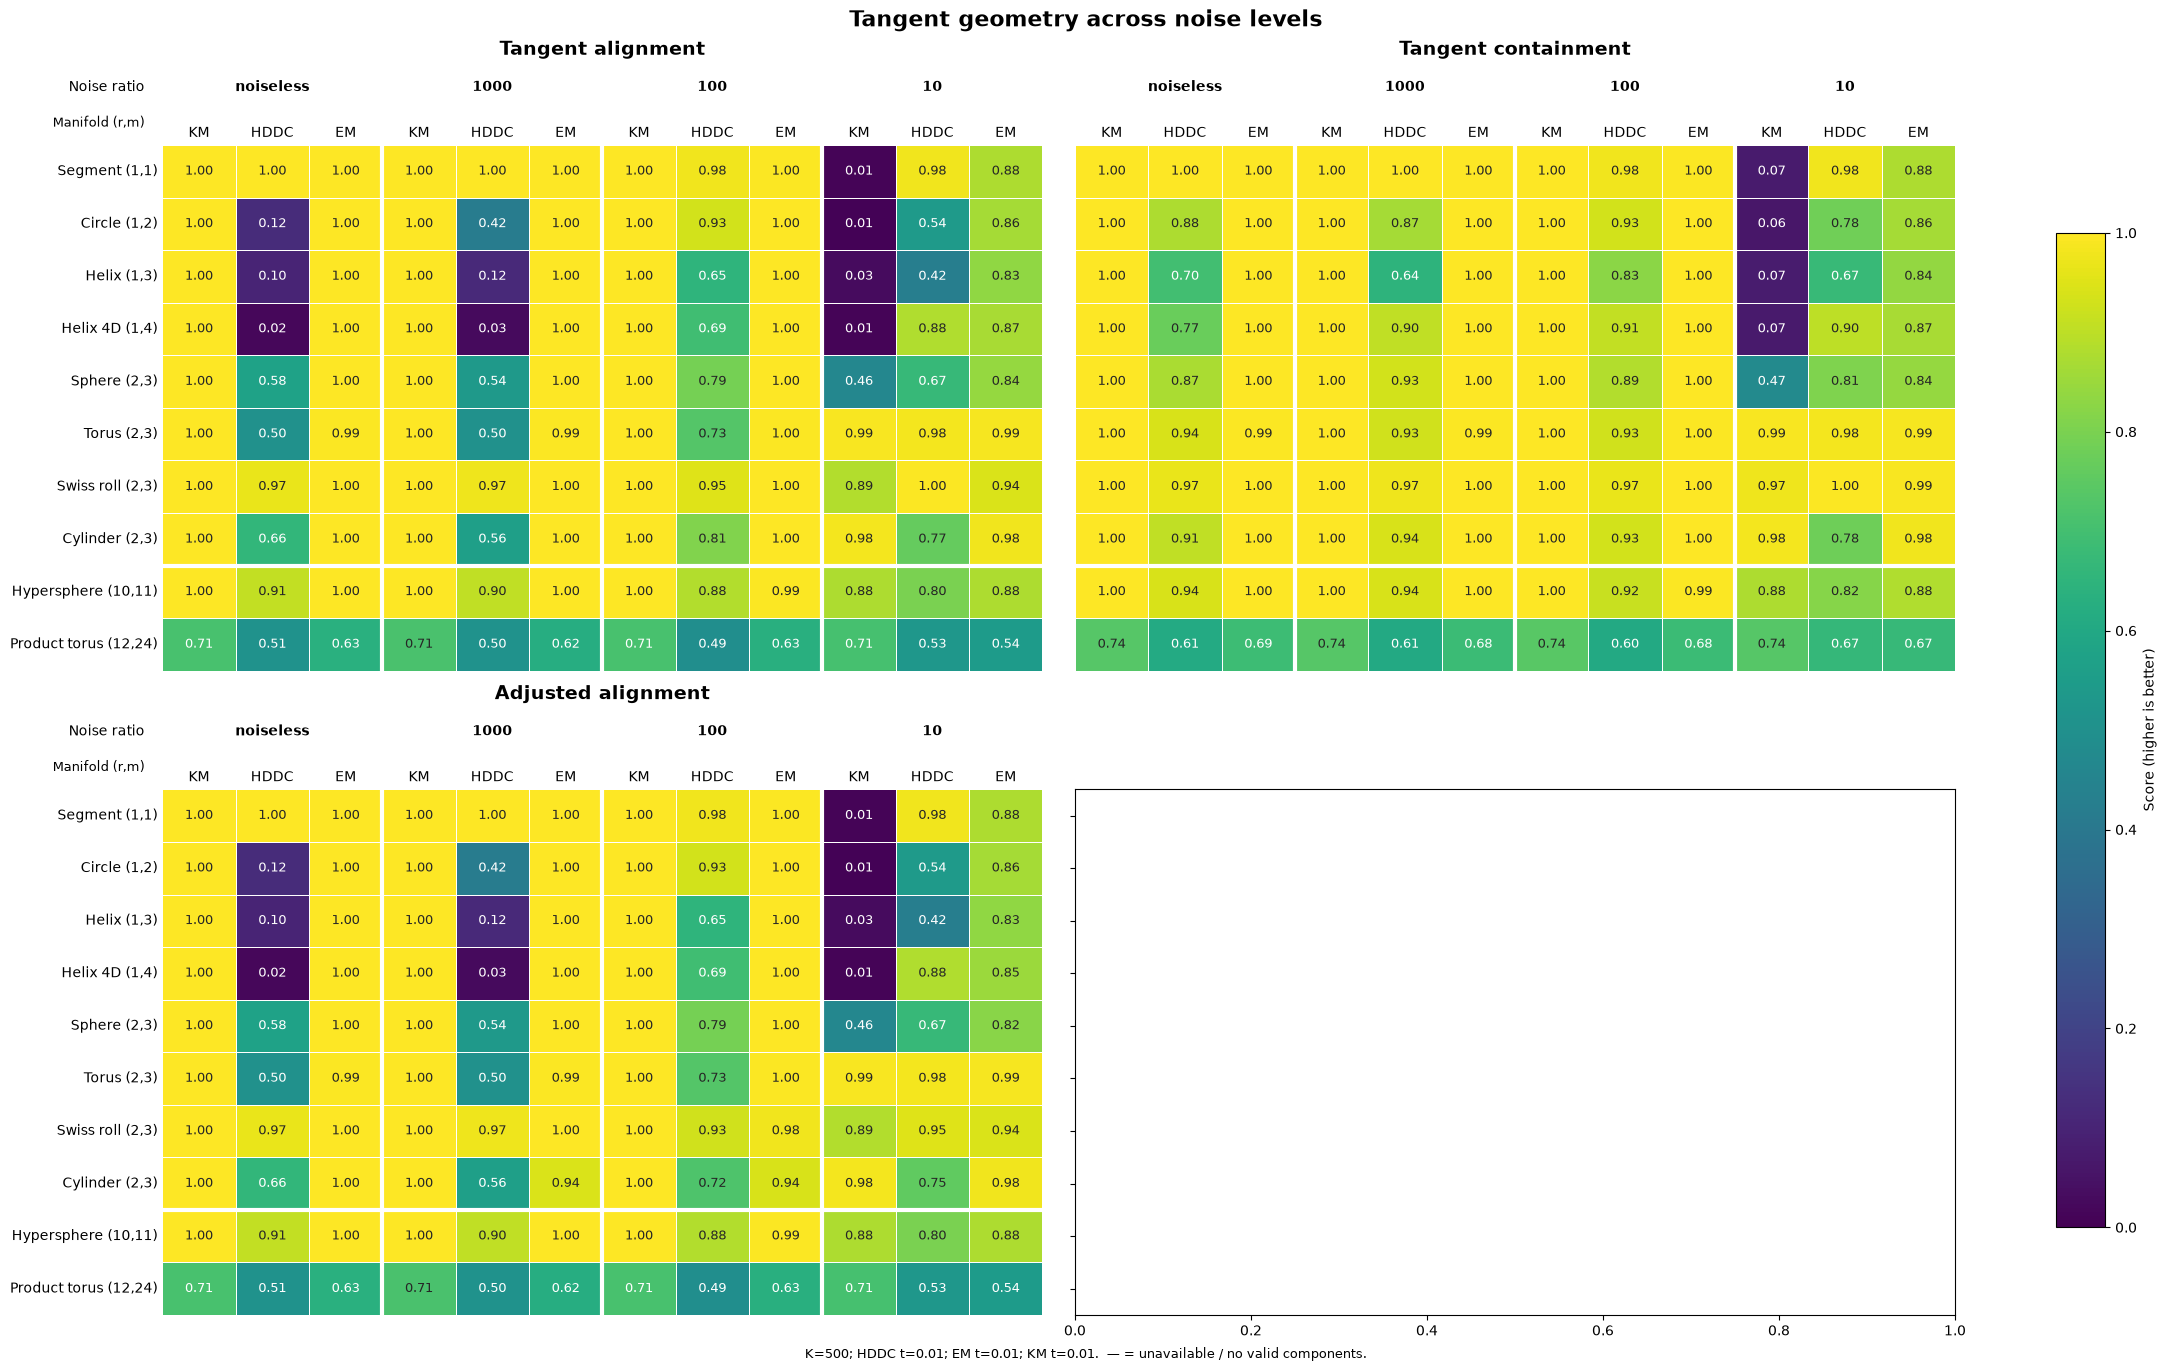

In [9]:
# Plot all selected tangent scores together; rerun this cell to change the presentation.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

model_labels = {"kmeans": "KM", "mfa": "MFA", "hddc": "HDDC", "em": "EM"}
manifold_names = {"helix_4d": "Helix 4D", "hypersphere_10d": "Hypersphere",
                  "product_torus_12d": "Product torus"}
row_labels = [
    f"{manifold_names.get(name, name.replace('_', ' ').capitalize())} ({row.intrinsic_dim},{row.embedding_dim})"
    for name, row in manifold_info.iterrows()
]

def plot_tangent_heatmap(ax, title, table, *, show_row_labels=True):
    """Draw one tangent panel with the dashboard labels and fixed 0–1 scale."""
    sns.heatmap(
        table, ax=ax, cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f", cbar=False,
        linewidths=0.5, linecolor="white", annot_kws={"fontsize": 9},
        xticklabels=[model_labels.get(model, model) for _, model in table.columns],
        yticklabels=row_labels,
    )
    ax.set_facecolor("#e9edf2")
    for row, col in np.argwhere(table.isna().to_numpy()):
        ax.text(col + 0.5, row + 0.5, "—", ha="center", va="center", color="#626b78", fontsize=10)

    ax.xaxis.tick_top()
    ax.tick_params(axis="both", length=0, labelrotation=0, labelsize=10)
    ax.tick_params(axis="y", labelleft=show_row_labels)
    ax.set(xlabel="", ylabel="", title="")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=65)
    if show_row_labels:
        ax.text(-0.02, 1.11, "Noise ratio", transform=ax.transAxes, ha="right", va="center", fontsize=10)
        ax.text(-0.02, 1.035, "Manifold (r,m)", transform=ax.transAxes, ha="right", fontsize=9)
    for group, noise in enumerate(NOISE_LEVELS):
        ax.text(group * len(MODELS) + len(MODELS) / 2, 1.11, str(noise),
                transform=ax.get_xaxis_transform(), ha="center", va="center", fontweight="bold")
        if group:
            ax.axvline(group * len(MODELS), color="white", linewidth=3)
    low_dim_rows = manifold_info["intrinsic_dim"].le(2).sum()
    if 0 < low_dim_rows < len(table):
        ax.axhline(low_dim_rows, color="white", linewidth=3)


panel_width = max(5.5, 0.8 + 0.75 * len(column_order))
fig, axes = plt.subplots(
    2, 2, figsize=(2 + 2 * panel_width, 2 * (2.6 + 0.42 * len(manifold_info))),
    sharey=True, squeeze=False, layout="constrained", facecolor="white",
)
fig.suptitle("Tangent geometry across noise levels", fontsize=16, fontweight="bold")
for panel, (title, table) in enumerate(tangent_tables.items()):
    ax = axes.flat[panel]
    plot_tangent_heatmap(ax, title, table, show_row_labels=(panel % 2 == 0))

fig.colorbar(axes[0, 0].collections[0], ax=list(axes.flat), label="Score (higher is better)", shrink=0.85)
settings = [f"K={K}"]
if "hddc" in MODELS:
    settings.append(f"HDDC t={HDDC_THRESHOLD:g}")
if "em" in MODELS:
    settings.append(f"EM t={EM_THRESHOLD:g}")
if "kmeans" in MODELS:
    settings.append(f"KM t={KMEANS_THRESHOLD:g}")
fig.supxlabel("; ".join(settings) + ".  — = unavailable / no valid components.", fontsize=9)
plt.show()


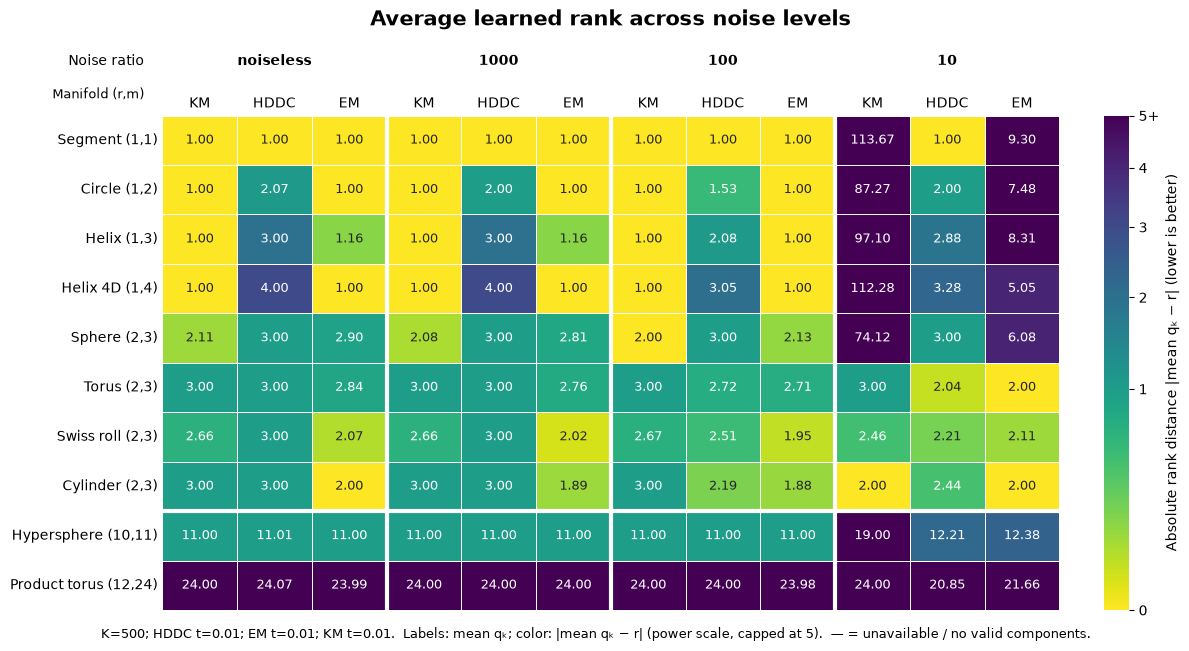

In [10]:
# Average learned rank for each manifold and selected model/noise configuration.
from matplotlib.colors import PowerNorm

RANK_DISTANCE_COLOR_MAX = 5  # Larger errors share the darkest color.
RANK_DISTANCE_COLOR_GAMMA = 0.5  # Emphasize differences near zero.

mean_rank_table = tangent_df.pivot(
    index="type_name", columns=["noise_ratio", "model_kind"], values="rank.mean_learned",
).reindex(index=manifold_info.index, columns=column_order)
rank_distance_table = mean_rank_table.sub(manifold_info["intrinsic_dim"], axis="index").abs()

fig, ax = plt.subplots(
    figsize=(max(6.5, 2.8 + 0.75 * mean_rank_table.shape[1]), 2.2 + 0.42 * len(mean_rank_table)),
    layout="constrained", facecolor="white",
)
sns.heatmap(
    rank_distance_table, ax=ax, cmap="viridis_r",
    norm=PowerNorm(gamma=RANK_DISTANCE_COLOR_GAMMA, vmin=0,
                   vmax=RANK_DISTANCE_COLOR_MAX, clip=True),
    annot=mean_rank_table, fmt=".2f", linewidths=0.5, linecolor="white", annot_kws={"fontsize": 9},
    xticklabels=[model_labels.get(model, model) for _, model in mean_rank_table.columns],
    yticklabels=row_labels, cbar_kws={"label": "Absolute rank distance |mean qₖ − r| (lower is better)"},
)
colorbar = ax.collections[0].colorbar
color_ticks = np.linspace(0, RANK_DISTANCE_COLOR_MAX, 6)
colorbar.set_ticks(color_ticks)
colorbar.set_ticklabels([f"{value:g}" for value in color_ticks[:-1]] + [f"{RANK_DISTANCE_COLOR_MAX:g}+"])
ax.set_facecolor("#e9edf2")
for row, col in np.argwhere(mean_rank_table.isna().to_numpy()):
    ax.text(col + 0.5, row + 0.5, "—", ha="center", va="center", color="#626b78", fontsize=10)

ax.xaxis.tick_top()
ax.tick_params(axis="both", length=0, labelrotation=0, labelsize=10)
ax.set(xlabel="", ylabel="", title="")
ax.set_title("Average learned rank across noise levels", fontsize=15, fontweight="bold", pad=65)
ax.text(-0.02, 1.11, "Noise ratio", transform=ax.transAxes, ha="right", va="center", fontsize=10)
ax.text(-0.02, 1.035, "Manifold (r,m)", transform=ax.transAxes, ha="right", fontsize=9)
for group, noise in enumerate(NOISE_LEVELS):
    ax.text(group * len(MODELS) + len(MODELS) / 2, 1.11, str(noise),
            transform=ax.get_xaxis_transform(), ha="center", va="center", fontweight="bold")
    if group:
        ax.axvline(group * len(MODELS), color="white", linewidth=3)
low_dim_rows = manifold_info["intrinsic_dim"].le(2).sum()
if 0 < low_dim_rows < len(mean_rank_table):
    ax.axhline(low_dim_rows, color="white", linewidth=3)

settings = [f"K={K}"]
if "hddc" in MODELS:
    settings.append(f"HDDC t={HDDC_THRESHOLD:g}")
if "em" in MODELS:
    settings.append(f"EM t={EM_THRESHOLD:g}")
if "kmeans" in MODELS:
    settings.append(f"KM t={KMEANS_THRESHOLD:g}")
fig.supxlabel("; ".join(settings) + f".  Labels: mean qₖ; color: |mean qₖ − r| (power scale, capped at {RANK_DISTANCE_COLOR_MAX:g}).  — = unavailable / no valid components.", fontsize=9)
plt.show()


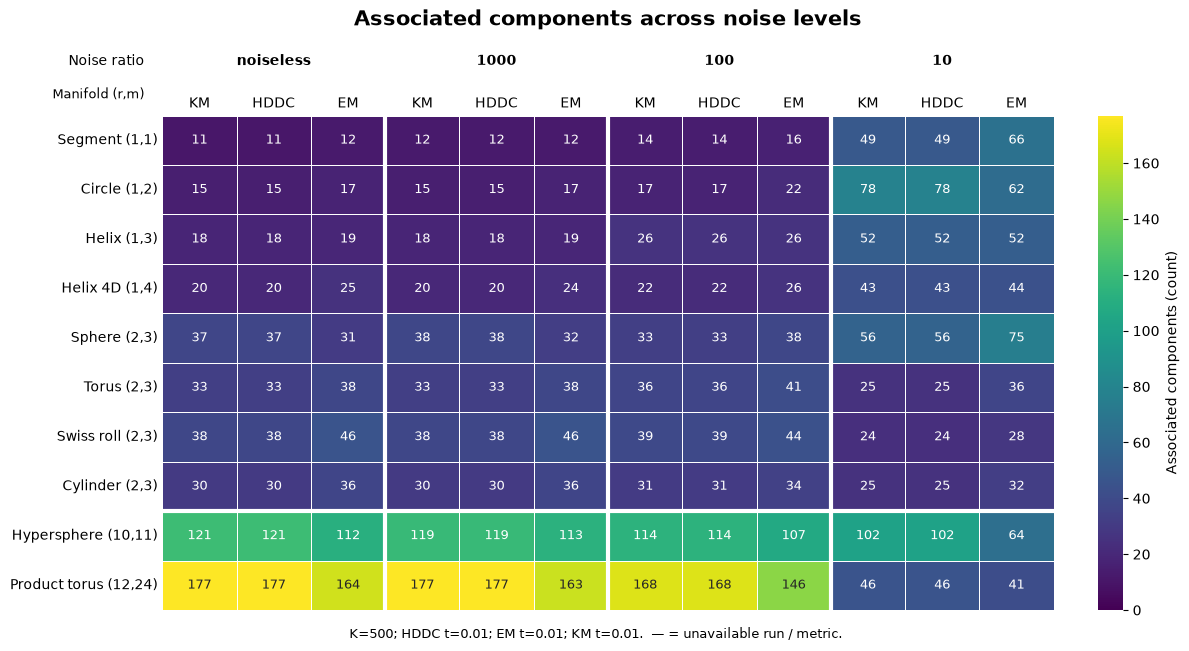

In [11]:
# Component counts for the same manifolds and selected model/noise configurations.
component_totals = tangent_df.groupby(["run_id", "K"])["components.associated"].sum()
assert (component_totals.to_numpy() == component_totals.index.get_level_values("K")).all(), (
    "Expected the manifold component counts to sum to K for each selected run."
)
component_count_table = tangent_df.pivot(
    index="type_name", columns=["noise_ratio", "model_kind"], values="components.associated",
).reindex(index=manifold_info.index, columns=column_order)

fig, ax = plt.subplots(
    figsize=(max(6.5, 2.8 + 0.75 * component_count_table.shape[1]), 2.2 + 0.42 * len(component_count_table)),
    layout="constrained", facecolor="white",
)
sns.heatmap(
    component_count_table, ax=ax, cmap="viridis", vmin=0,
    vmax=None if component_count_table.notna().any().any() else 1,
    annot=True, fmt=".0f", linewidths=0.5, linecolor="white", annot_kws={"fontsize": 9},
    xticklabels=[model_labels.get(model, model) for _, model in component_count_table.columns],
    yticklabels=row_labels, cbar_kws={"label": "Associated components (count)"},
)
ax.set_facecolor("#e9edf2")
for row, col in np.argwhere(component_count_table.isna().to_numpy()):
    ax.text(col + 0.5, row + 0.5, "—", ha="center", va="center", color="#626b78", fontsize=10)

ax.xaxis.tick_top()
ax.tick_params(axis="both", length=0, labelrotation=0, labelsize=10)
ax.set(xlabel="", ylabel="", title="")
ax.set_title("Associated components across noise levels", fontsize=15, fontweight="bold", pad=65)
ax.text(-0.02, 1.11, "Noise ratio", transform=ax.transAxes, ha="right", va="center", fontsize=10)
ax.text(-0.02, 1.035, "Manifold (r,m)", transform=ax.transAxes, ha="right", fontsize=9)
for group, noise in enumerate(NOISE_LEVELS):
    ax.text(group * len(MODELS) + len(MODELS) / 2, 1.11, str(noise),
            transform=ax.get_xaxis_transform(), ha="center", va="center", fontweight="bold")
    if group:
        ax.axvline(group * len(MODELS), color="white", linewidth=3)
low_dim_rows = manifold_info["intrinsic_dim"].le(2).sum()
if 0 < low_dim_rows < len(component_count_table):
    ax.axhline(low_dim_rows, color="white", linewidth=3)

settings = [f"K={K}"]
if "hddc" in MODELS:
    settings.append(f"HDDC t={HDDC_THRESHOLD:g}")
if "em" in MODELS:
    settings.append(f"EM t={EM_THRESHOLD:g}")
if "kmeans" in MODELS:
    settings.append(f"KM t={KMEANS_THRESHOLD:g}")
fig.supxlabel("; ".join(settings) + ".  — = unavailable run / metric.", fontsize=9)
plt.show()


## 5. One heatmap for a report

Run the data-selection and plotting cells for the dashboard you want first:
- `"sweep"`: **K and rank selection at a glance** (originally `In [3]`). Choose one model, noise ratio, and metric from `sweep_tables`.
- `"tangent"`: **Tangent geometry** (originally `In [9]`). Choose `"Tangent alignment"`, `"Tangent containment"`, or `"Adjusted alignment"` from `tangent_tables`.

Execution numbers can change; the section names above identify the source. This cell redraws one panel using the same data, color scale, annotations, and missing-value markers. The selections in the earlier cells still apply. For fewer tangent columns, edit `NOISE_LEVELS` / `MODELS` there and rerun that section.

Edit the commented settings below, then run the cell. `REPORT_FIGSIZE` is `(width, height)` in inches. Uncomment the export lines for a vector PDF or a 300-dpi PNG. Repeat with another metric to make another report figure.


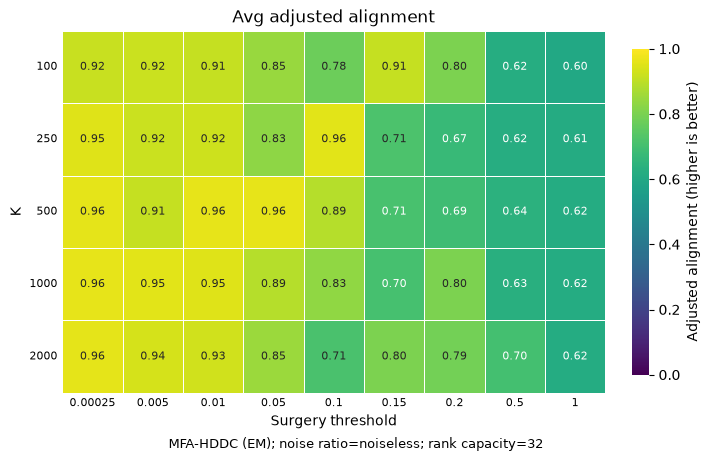

In [14]:
# --- Choose ONE heatmap ---
REPORT_SOURCE = "sweep"  # "sweep" (original In [3]) or "tangent" (original In [9])
REPORT_METRIC = "Avg adjusted alignment"  # For tangent, e.g. "Adjusted alignment".
# Sweep metrics: "qₖ = r (%)", "qₖ = m (%)", "Mean qₖ", "NLL (validation)",
# "Live / total components", "Avg tangent alignment", "Avg tangent containment",
# "Avg adjusted alignment", "Adjusted BIC", "Regular BIC".
# These must be included in SWEEP_METRICS above.
REPORT_MODEL = "em"  # Sweep only: "hddc", "em", "kmeans", or "mfa".
REPORT_NOISE = "noiseless"  # Sweep only; "noiseless" is also supported.

# --- Report presentation ---
REPORT_FIGSIZE = (7, 4.5)  # Inches; increase width for many tangent columns.
REPORT_TITLE = None  # None keeps the metric title; use "" to remove it.

# Reuse the dashboard renderers so metric-specific scales stay consistent.
assert REPORT_SOURCE in {"sweep", "tangent"}, "Choose 'sweep' or 'tangent'."
if REPORT_SOURCE == "sweep":
    report_key = (REPORT_MODEL, noise_key(REPORT_NOISE))
    assert report_key in sweep_tables, f"Choose a model/noise pair from {list(sweep_tables)}"
    report_tables = sweep_tables[report_key]
else:
    report_tables = tangent_tables
assert REPORT_METRIC in report_tables, f"Choose a metric from {list(report_tables)}"
report_table = report_tables[REPORT_METRIC]

report_fig, report_ax = plt.subplots(
    figsize=REPORT_FIGSIZE, layout="constrained", facecolor="white",
)
if REPORT_SOURCE == "sweep":
    plot_sweep_heatmap(report_ax, REPORT_METRIC, report_table, REPORT_MODEL)
    # Keep the run settings in a compact caption for the report.
    report_caption = f"{sweep_model_names[REPORT_MODEL]}; noise ratio={report_key[1]}"
    if REPORT_MODEL != "kmeans":
        report_caption += f"; rank capacity={SWEEP_Q_CAPACITY}"
else:
    plot_tangent_heatmap(report_ax, REPORT_METRIC, report_table)
    report_fig.colorbar(
        report_ax.collections[0], ax=report_ax, label="Score (higher is better)", shrink=0.85,
    )
    report_settings = [f"K={K}"]
    for model, threshold in [("hddc", HDDC_THRESHOLD), ("em", EM_THRESHOLD),
                             ("kmeans", KMEANS_THRESHOLD)]:
        if model in MODELS:
            report_settings.append(f"{model_labels[model]} t={threshold:g}")
    report_caption = "; ".join(report_settings)
if REPORT_TITLE is not None:
    report_ax.set_title(REPORT_TITLE)
report_fig.supxlabel(report_caption, fontsize=9)

# --- Optional export: change the filename for each selected heatmap ---
# report_dir = REPO_ROOT / "outputs" / "report_figures"
# report_dir.mkdir(parents=True, exist_ok=True)
# report_fig.savefig(report_dir / "selected_heatmap.pdf", bbox_inches="tight")
# report_fig.savefig(report_dir / "selected_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Held-out coverage over radius

Run the loading and rank-recovery selection cells first. This section reuses `runs`, so `K`, `HDDC_THRESHOLD`, `EM_THRESHOLD`, and `KMEANS_THRESHOLD` select the same configurations as the rank table. Choose models and noise levels below; each noise level gets a panel with common axes for comparison.

Coverage at radius **r** is the fraction of independent `test/` points whose Euclidean distance to the nearest **training-live centroid** is at most r. Higher coverage at a fixed radius is better. Curves are full empirical CDFs, drawn as steps without interpolation or subsampling; they are run-level scores, not averages over manifold types.

The curves come from `heldout_distribution_coverage.coverage_curve` in `general_metrics.csv`. If coverage is missing, finish the coverage-enabled evaluation and CSV collection, then rerun the loading and selection cells.


In [15]:
# Select curves from the same runs as the rank-recovery table.
import json

COVERAGE_MODELS = ["kmeans", "mfa", "hddc", "em"]
COVERAGE_NOISE_LEVELS = ["noiseless", 1000, 100, 10]
COVERAGE_CURVE_COLUMN = "heldout_distribution_coverage.coverage_curve"

assert COVERAGE_MODELS and COVERAGE_NOISE_LEVELS, "Select at least one model and noise level."
coverage_noise_levels = [noise_key(noise) for noise in COVERAGE_NOISE_LEVELS]
if COVERAGE_CURVE_COLUMN not in runs:
    raise ValueError("Coverage is missing. Finish reevaluation and CSV collection, then reload and reselect runs.")
coverage_runs = runs.loc[
    runs["model_kind"].isin(COVERAGE_MODELS) & runs["noise_ratio"].isin(coverage_noise_levels)
].copy()
assert not coverage_runs.duplicated(["noise_ratio", "model_kind"]).any(), "Select one run per noise level and model."
coverage_curves = {}
for noise in coverage_noise_levels:
    for model in COVERAGE_MODELS:
        selected_curve = coverage_runs.loc[
            coverage_runs["noise_ratio"].eq(noise) & coverage_runs["model_kind"].eq(model)
        ]
        if selected_curve.empty or selected_curve[COVERAGE_CURVE_COLUMN].isna().any():
            raise ValueError(f"Missing coverage for {model}, noise={noise}. Check selections, finish CSV collection, and reload.")
        curve = pd.DataFrame(json.loads(selected_curve.iloc[0][COVERAGE_CURVE_COLUMN]))
        assert not curve.empty and {"radius", "fraction"}.issubset(curve.columns), "Expected an empirical coverage curve."
        coverage_curves[(noise, model)] = curve
print(f"Selected {len(coverage_curves)} full empirical coverage curves at K={K}.")


Selected 16 full empirical coverage curves at K=500.


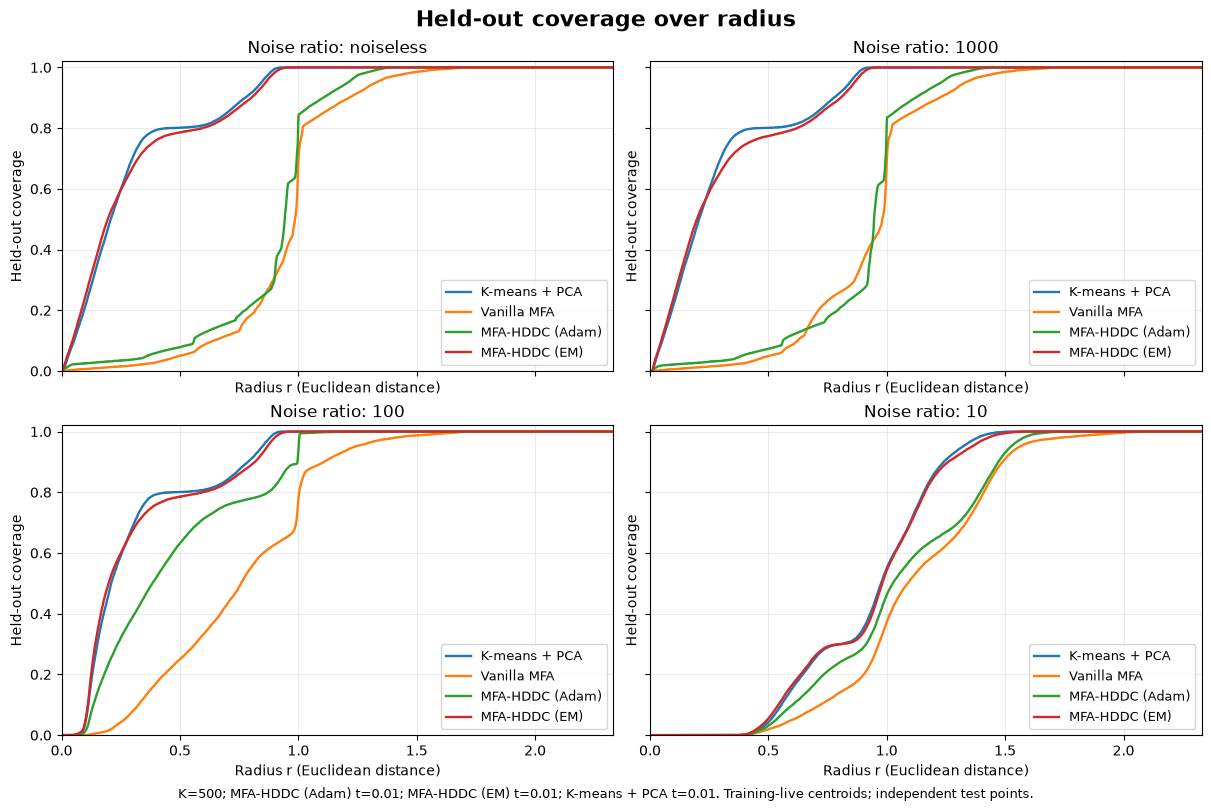

In [16]:
# One panel per noise level; consistent model colors and common radius/coverage axes.
import matplotlib.pyplot as plt
import numpy as np

coverage_colors = dict(zip(MODEL_NAMES, plt.get_cmap("tab10").colors))
coverage_ncols = min(2, len(coverage_noise_levels))
coverage_nrows = (len(coverage_noise_levels) + coverage_ncols - 1) // coverage_ncols
coverage_fig, coverage_axes = plt.subplots(
    coverage_nrows, coverage_ncols, figsize=(6 * coverage_ncols, 4 * coverage_nrows),
    sharex=True, sharey=True, squeeze=False, layout="constrained", facecolor="white",
)
coverage_max_radius = max(curve["radius"].max() for curve in coverage_curves.values())
coverage_radius_limit = 1.02 * coverage_max_radius if coverage_max_radius > 0 else 1.0
for ax, noise in zip(coverage_axes.flat, coverage_noise_levels):
    for model in COVERAGE_MODELS:
        curve = coverage_curves[(noise, model)]
        # Start at zero and extend the final plateau across the common radius range.
        ax.step(
            np.r_[0.0, curve["radius"].to_numpy(), coverage_radius_limit],
            np.r_[0.0, curve["fraction"].to_numpy(), 1.0],
            where="post", label=MODEL_NAMES[model], color=coverage_colors[model], linewidth=1.7,
        )
    ax.set(title=f"Noise ratio: {noise}", xlabel="Radius r (Euclidean distance)",
           ylabel="Held-out coverage", xlim=(0, coverage_radius_limit), ylim=(0, 1.02))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc="lower right")
for ax in list(coverage_axes.flat)[len(coverage_noise_levels):]:
    ax.set_visible(False)
coverage_fig.suptitle("Held-out coverage over radius", fontsize=16, fontweight="bold")
coverage_settings = [f"K={K}"]
for model, threshold in [("hddc", HDDC_THRESHOLD), ("em", EM_THRESHOLD), ("kmeans", KMEANS_THRESHOLD)]:
    if model in COVERAGE_MODELS:
        coverage_settings.append(f"{MODEL_NAMES[model]} t={threshold:g}")
coverage_fig.supxlabel("; ".join(coverage_settings) + ". Training-live centroids; independent test points.", fontsize=9)
# Optional export:
# coverage_fig.savefig(REPO_ROOT / "outputs" / "heldout_coverage.pdf", bbox_inches="tight")
plt.show()
